In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [33]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'exercises_dataset_CLEAN.csv'

df = pd.read_csv(file_path)

In [35]:
df.label.unique()

<StringArray>
[      'Abs/Core',           'Legs',           'Back',          'Chest',
           'Arms',   'Cardio/Plyos', 'Shoulders/Neck',     'Stretching']
Length: 8, dtype: str

In [18]:
df.head()

,exercise,label
0,3/4 sit-up,Abs/Core
1,45° side bend,Abs/Core
2,air bike,Abs/Core
3,all fours squad stretch,Legs
4,alternate heel touchers,Abs/Core


In [46]:
df.label.value_counts()

label
Legs              1109
Abs/Core           819
Arms               671
Back               540
Shoulders/Neck     471
Chest              421
Stretching         147
Cardio/Plyos        64
Name: count, dtype: int64

In [36]:
X = df['exercise']
y = df['label']

# Basic Term Frequency Model

In [37]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [38]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=290726)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
print(scores.mean(), scores.std())

0.7234310483229364 0.02380898226981918


In [39]:
scores

array([0.77655082, 0.73359855, 0.67997296, 0.71955587, 0.73727107,
       0.73275814, 0.7137835 , 0.71221877, 0.7236785 , 0.70492231])

## Look at one sample

In [40]:
train = df.sample(frac = 0.7, random_state = 290726)

In [41]:
X_train = np.array(train['exercise'])
y_train = np.array(train['label'])

In [42]:
test = df[~df.index.isin(train['exercise'].index)]
X_test = np.array(test['exercise'])
y_test = np.array(test['label'])

In [43]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](8,)","['Abs/Core','Arms','Back',...,'Legs','Shoulders/Neck','Stretching']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",

In [44]:
y_pred = pipe.predict(X_test)

                precision    recall  f1-score   support

      Abs/Core       0.78      0.76      0.77       244
          Arms       0.93      0.85      0.89       205
          Back       0.71      0.77      0.74       159
  Cardio/Plyos       0.24      0.69      0.36        16
         Chest       0.78      0.86      0.82       142
          Legs       0.89      0.71      0.79       330
Shoulders/Neck       0.75      0.82      0.79       131
    Stretching       0.47      0.70      0.56        46

      accuracy                           0.78      1273
     macro avg       0.69      0.77      0.71      1273
  weighted avg       0.80      0.78      0.78      1273



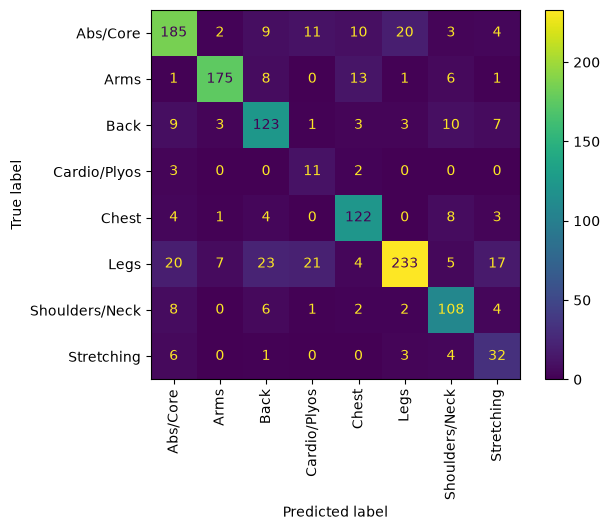

In [45]:
# 3. Per-class precision/recall/F1 — more informative than accuracy alone
print(classification_report(y_test, y_pred))

# 4. Confusion matrix — shows which categories get confused with each other
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=90)

# Linear SVM Pipeline

In [47]:
linear_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english")),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
])


In [48]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=290726)
scores = cross_val_score(linear_pipe, X, y, cv=cv, scoring='f1_macro')
print(scores.mean(), scores.std())

0.7248710910249219 0.03490365297051827


# Previous Suggested Pipeline

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# word + char n-grams together — char n-grams catch shared roots like
# "jump"/"jumping" and "stretch"/"stretching" even with different suffixes
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1,2), min_df=1, stop_words="english")),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=1)),
])

svm_pipe = Pipeline([("feats", vectorizer), ("clf", LinearSVC(class_weight="balanced", max_iter=5000))])
nb_pipe  = Pipeline([("feats", vectorizer), ("clf", ComplementNB())])

cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)
for name, pipe in [("SVM", svm_pipe), ("ComplementNB", nb_pipe)]:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(name, scores.mean(), scores.std())

SVM 0.7320022086977496 0.018213122868077414
ComplementNB 0.6872180768232297 0.013005378853655917
